In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [13]:
# Load built-in dataset
iris = load_iris()

## Exploratory Data Analysis 

In [14]:
# Convert dataset to a Pandas DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Map target numbers (0, 1, 2) to actual flower species names
species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
df['species'] = df['species'].map(species_map)

# Display shape of the first 5 rows
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [15]:
# Check data types, non-null counts, and summary statistics
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Visualizations of species

In [16]:
# Check total count of missing/null values 
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


### No missing value found

In [17]:
#check for duplicate values
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1


### one duplicate row found

In [18]:
# Drop the duplicate row
df = df.drop_duplicates().reset_index(drop=True)

In [19]:
# Verify duplicate count is now 0
print("Duplicate rows remaining:", df.duplicated().sum())

Duplicate rows remaining: 0


### Duplicate row dropped

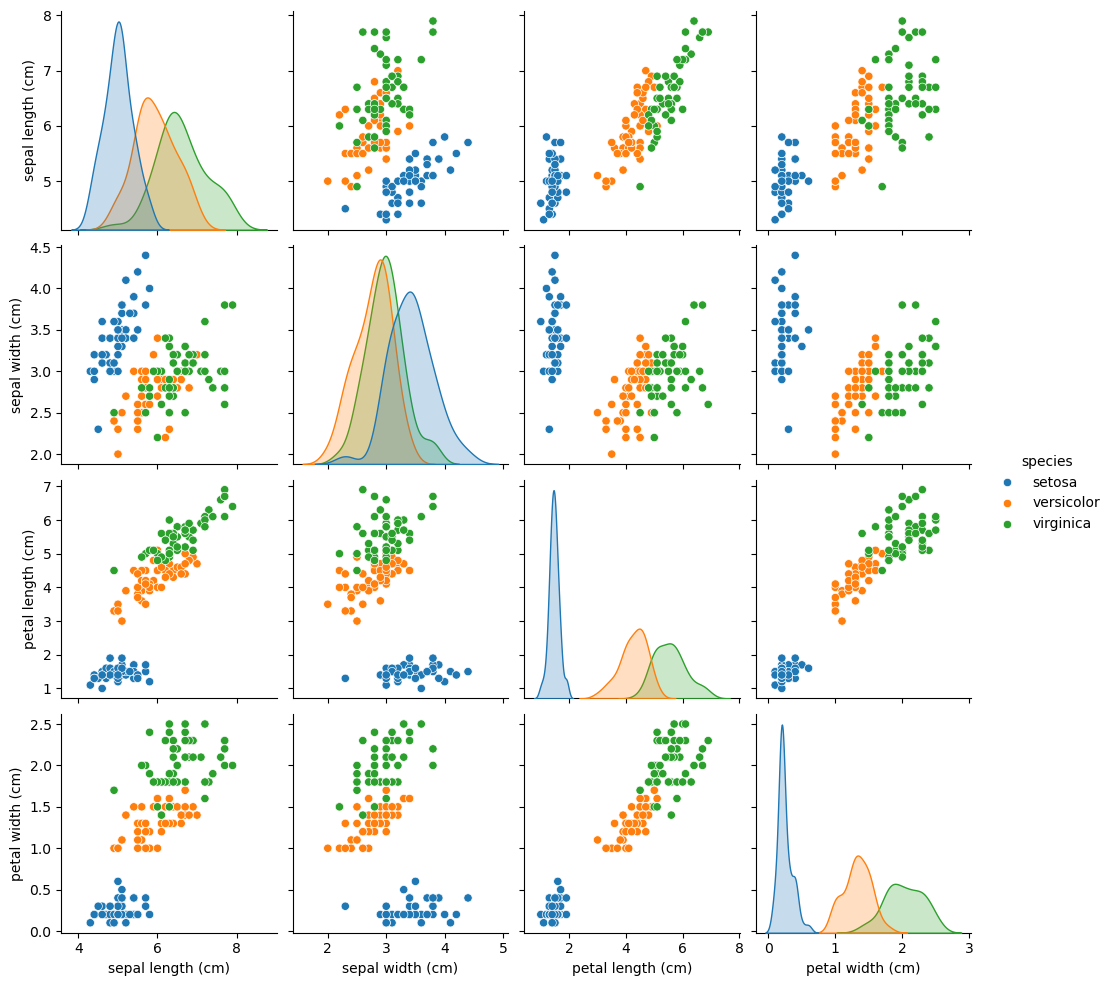

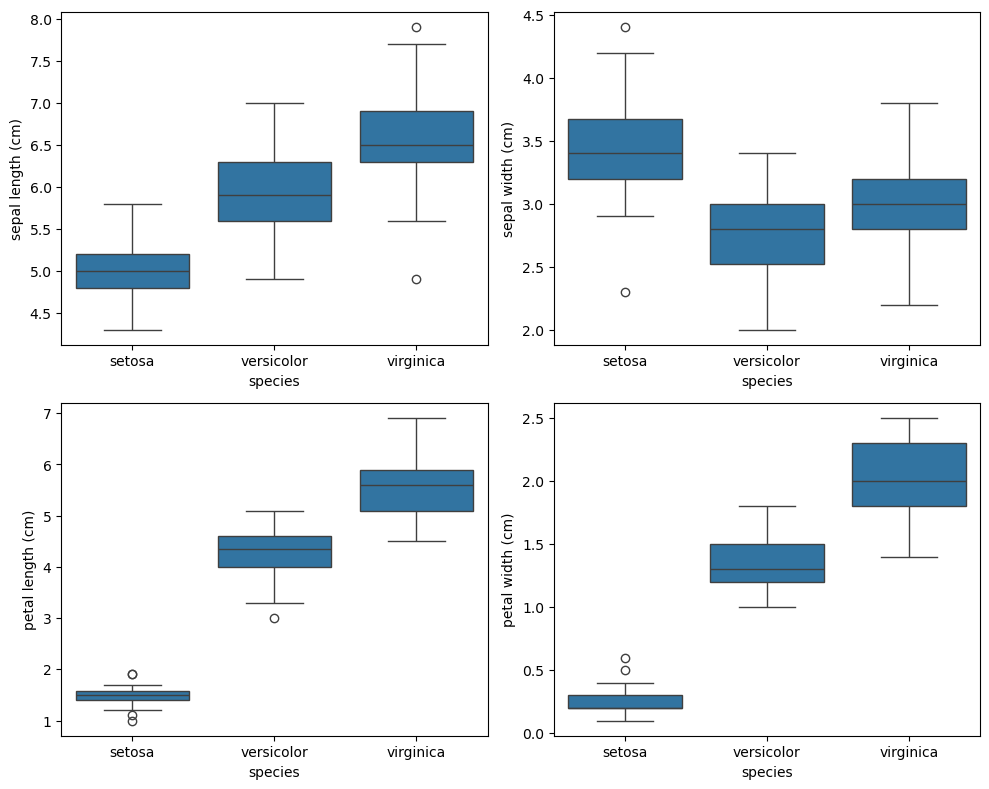

In [20]:
# Pairplot to check feature relationships across species
sns.pairplot(df, hue='species')
plt.show()

# Boxplots for individual feature distribution
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

sns.boxplot(ax=axes[0, 0], x='species', y='sepal length (cm)', data=df)
sns.boxplot(ax=axes[0, 1], x='species', y='sepal width (cm)', data=df)
sns.boxplot(ax=axes[1, 0], x='species', y='petal length (cm)', data=df)
sns.boxplot(ax=axes[1, 1], x='species', y='petal width (cm)', data=df)

plt.tight_layout()
plt.show()

## Feature Selection Discussion: Looking at the pairplot and box plots above, a few key patterns stand out:                                          1. Petal measurements (length & width) are the best predictors. Setosa is completely separated from the other two species on every petal graph—its petals are much shorter (under 2 cm) and narrower (under 0.8 cm). There is also very little overlap between versicolor and virginica, as seen in the box plots where their median values and boxes stay mostly distinct.                                                                                  2. Sepal measurements (length & width) are much less helpful on their own. The graphs for sepal length and width show a lot of overlap among all three species. Versicolor and virginica look especially crowded together on these plots, making it hard to draw a clean boundary between them using sepal size alone.                                                                                                Conclusion: Petal length and petal width do most of the heavy lifting for telling the flower species apart. I will keep all four features in X for model training, but petal dimensions are clearly the most discriminative.

# Train/Test Split

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [22]:
# Train/Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

NameError: name 'X' is not defined

In [ ]:
# Train Logistic Regression
log_reg = LogisticRegression(max_iter=200, random_state=42)
log_reg.fit(X_train, y_train)

In [ ]:
# Train Random Forest
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)

## Evalaution of Logistic and Random Forest Models 

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Store models in a dictionary for easy looping
models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf_clf
}

In [ ]:
# Evaluate Logistic Regression
log_preds = log_reg.predict(X_test)
print("--- Logistic Regression ---")
print("Accuracy:", accuracy_score(y_test, log_preds))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, log_preds))
print("\nClassification Report:\n", classification_report(y_test, log_preds))

print("\n" + "="*40 + "\n")

# Evaluate Random Forest
rf_preds = rf_clf.predict(X_test)
print("--- Random Forest ---")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_preds))
print("\nClassification Report:\n", classification_report(y_test, rf_preds))



### Best Performing Model & Justification

Best Model: Logistic Regression

Key Metrics Comparison:

Logistic Regression: Accuracy of 96.67% (29/30 correctly classified)
Random Forest: Accuracy of 90.00% (27/30 correctly classified)

Justification:
Logistic Regression outperformed Random Forest on the test set. It misclassified only a single sample (*versicolor* as *virginica*), whereas Random Forest misclassified three samples.

Because the Iris dataset is small and features like petal length and width are linearly separable, a linear model like Logistic Regression fits the data better without overfitting, unlike an ensemble tree-based model.

In [ ]:
import joblib

# Load model back in
clf = joblib.load('iris_model.pkl')

# Test sample input: [sepal length, sepal width, petal length, petal width]
sample = [[5.1, 3.5, 1.4, 0.2]]
print(clf.predict(sample))